Modeling Plan:
1. Data pretreatment: Load the data, handle missing values and inconsistent feature counts, normalize data sets.
2. Calculate PCA models for faulty turbines and the healthy turbine. For faulty turbines, use only the first 20 time series data points.
3. Identify the two most important sensors by comparing the PCA results between the faulty ones and the healthy one.
4. Train a PLS model to predict the values of these two sensors by using the other sensor values. Training to be done using the healthy turbine.
5. Test the model accuracy on one faulty turbine


### 0. Setting up the environment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from seaborn import heatmap
from sklearn.decomposition import PCA
import os

if not os.path.exists('Plots'):
    os.makedirs('Plots')

### 1. Data loading, pretreatment and visualization
Wind turbine with 31 variables is ignored, since it would be difficult to compare it to other wind turbines since the order of the sensors would not be guaranteed to be correct. Two remaining faulty turbines have 27 variables whereas the healthy turbine has 28 variables, so we remove the last column of the healthy turbine (WT2).

Missing values (which there are only one) are handled with linear interpolation.

In [2]:
data = {}
sheet_names = ["No.2WT", "No.3", "No.14WT", "No.39WT"]

for sheet in sheet_names:
    df = pd.read_excel("data.xlsx", sheet_name=sheet)

    if df.shape[1] > 28:
        print(f"Skipping turbine {sheet} with {df.shape[1]} columns.")
        continue
    elif df.shape[1] == 28:
        print(f"Removing last column of turbine {sheet} to match other turbines.")
        df = df.iloc[:, :-1]

    # Preprocessing: missing values are handled by interpolation
    nan_locations = df.isna()
    # Print the locations of nan values
    if nan_locations.any().any():
        print(f"Missing values (NaN) in turbine {sheet} data set: {nan_locations[nan_locations].stack().index.tolist()}")
    # Interpolate missing values
    df = df.interpolate(method='linear', limit_direction='both')

    data[sheet] = df

def normalize_dataframe(df, mean=None, std=None):
    # Z-score normalization
    if mean is None: mean = df.mean()
    if std is None: std = df.std()
    
    df_norm = (df - mean) / std
    # Replace any NaN or inf values resulting from zero std with 0
    df_norm = df_norm.replace([np.inf, -np.inf], np.nan).fillna(0)
    return df_norm

Removing last column of turbine No.2WT to match other turbines.
Skipping turbine No.3 with 31 columns.
Missing values (NaN) in turbine No.14WT data set: [(357, 9)]


For better understanding what data we are dealing with, let's visualize it with a few different ways:
- Plot the variable correlations to see which sensors are correlating with each other
- Plot the variable distributions to see in what range are the sensors getting values and with what kind of variance
- Plot the sensor data as time series plot to see how the values for the sensors behave over time (with this it is also easy to see when the faulty turbines stop working)

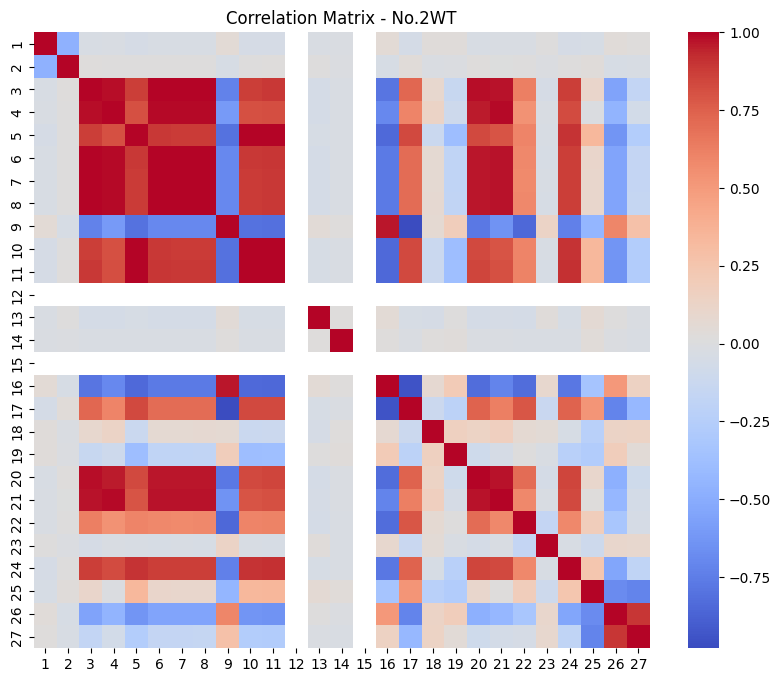

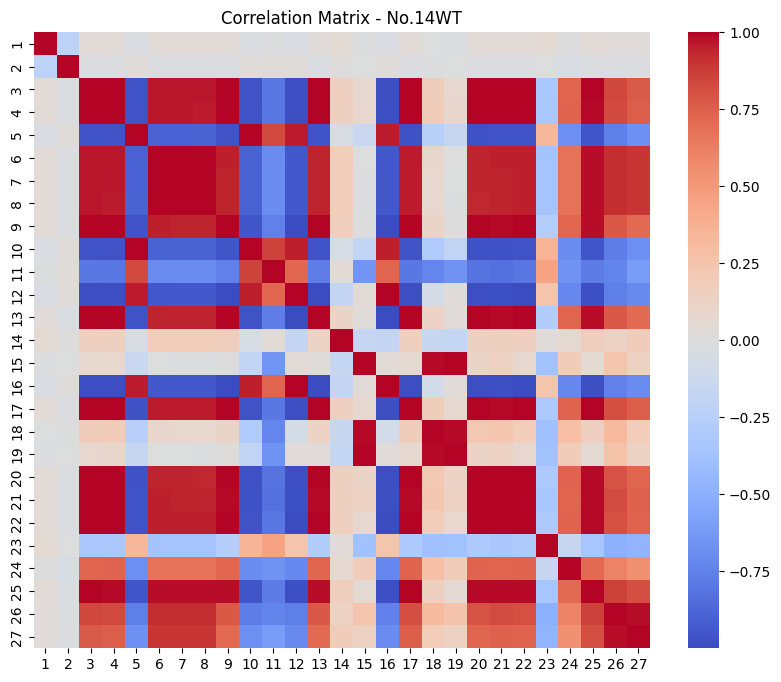

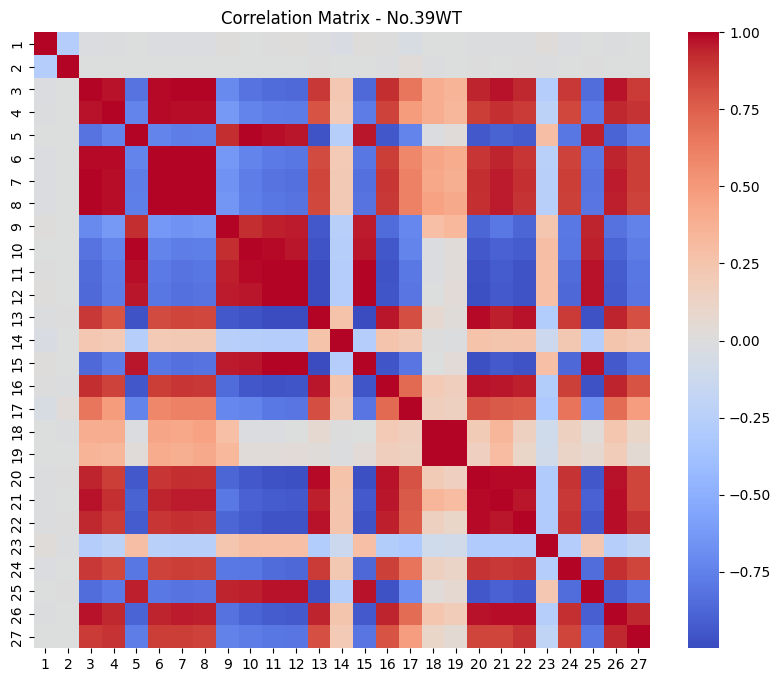

In [3]:
# Correlation matrices
for sheet_name, df in data.items():
    df_norm = normalize_dataframe(df)
    corr_matrix = df_norm.corr()
    plt.figure(figsize=(10, 8))
    heatmap(corr_matrix, cmap='coolwarm', square=True)
    plt.title(f"Correlation Matrix - {sheet_name}")
    plt.savefig(f"Plots/Correlation_Matrix_{sheet_name}.svg")
    plt.show()

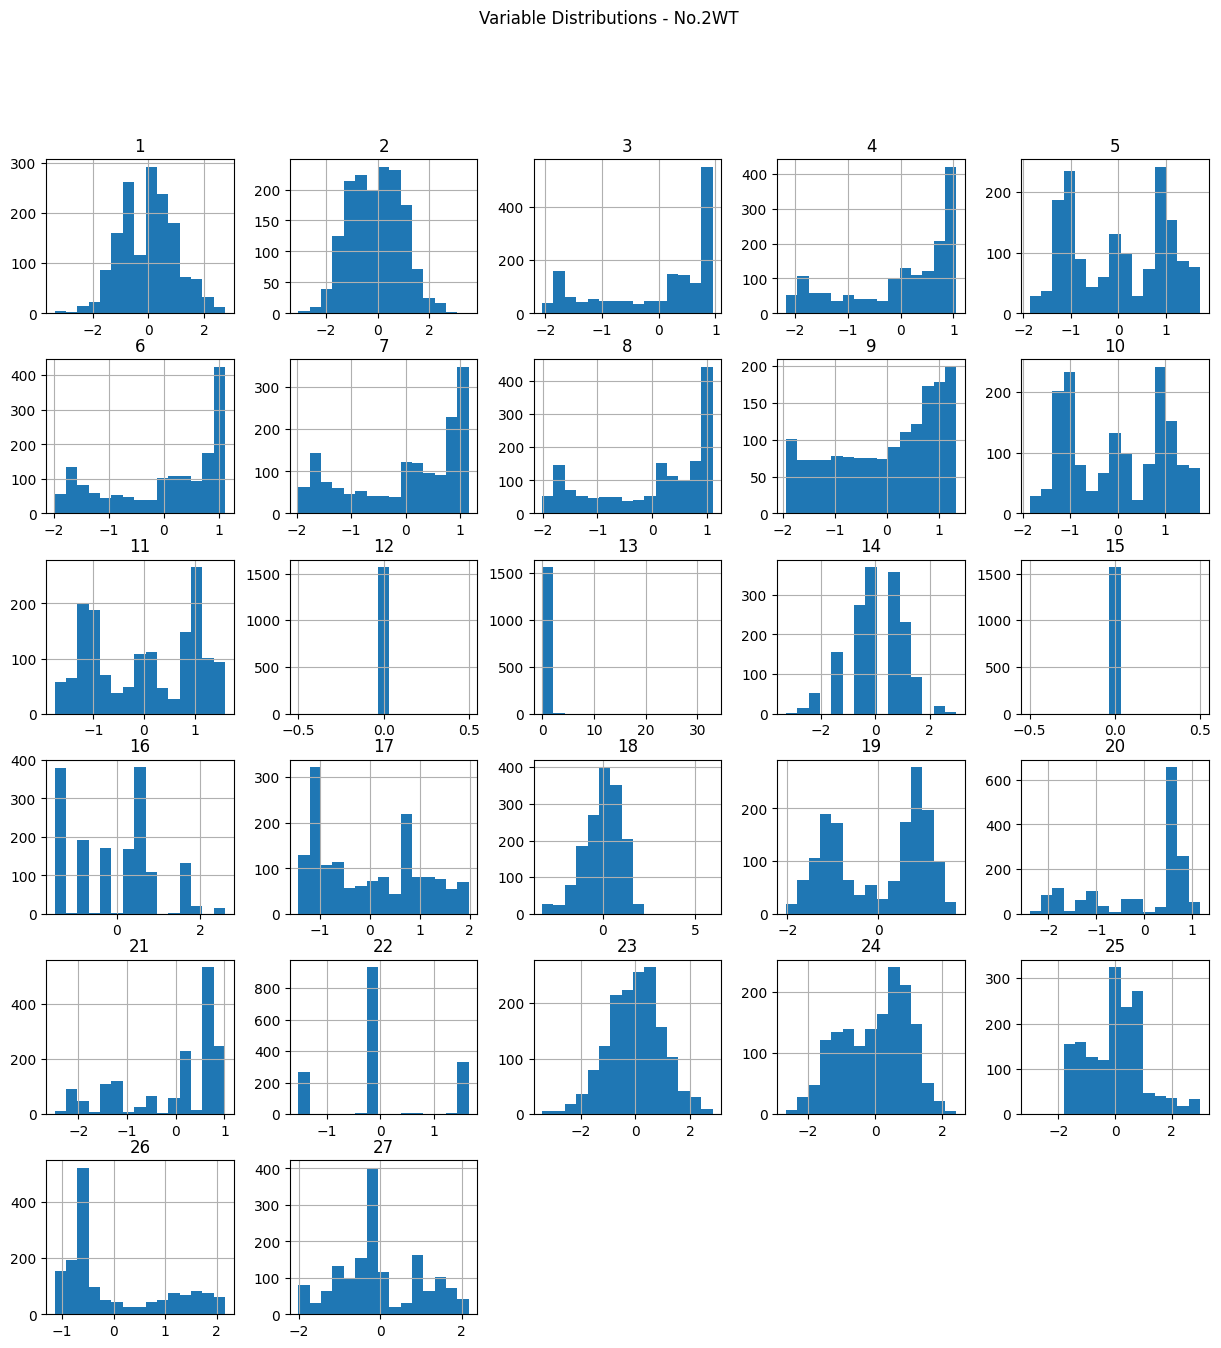

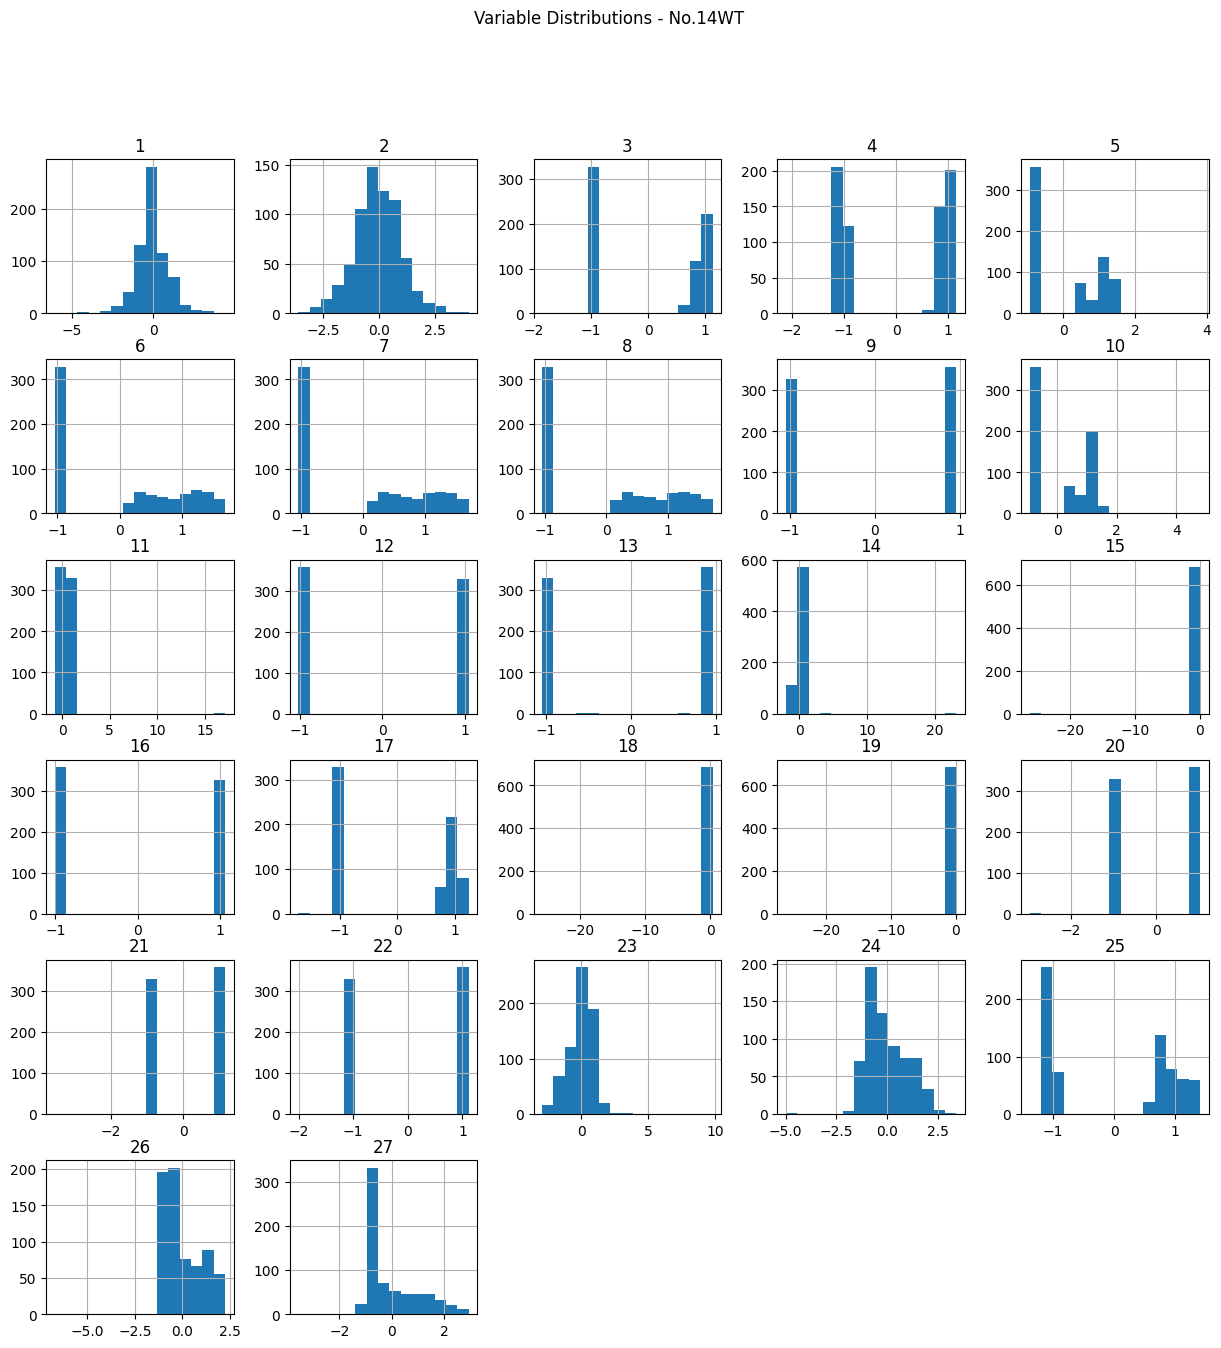

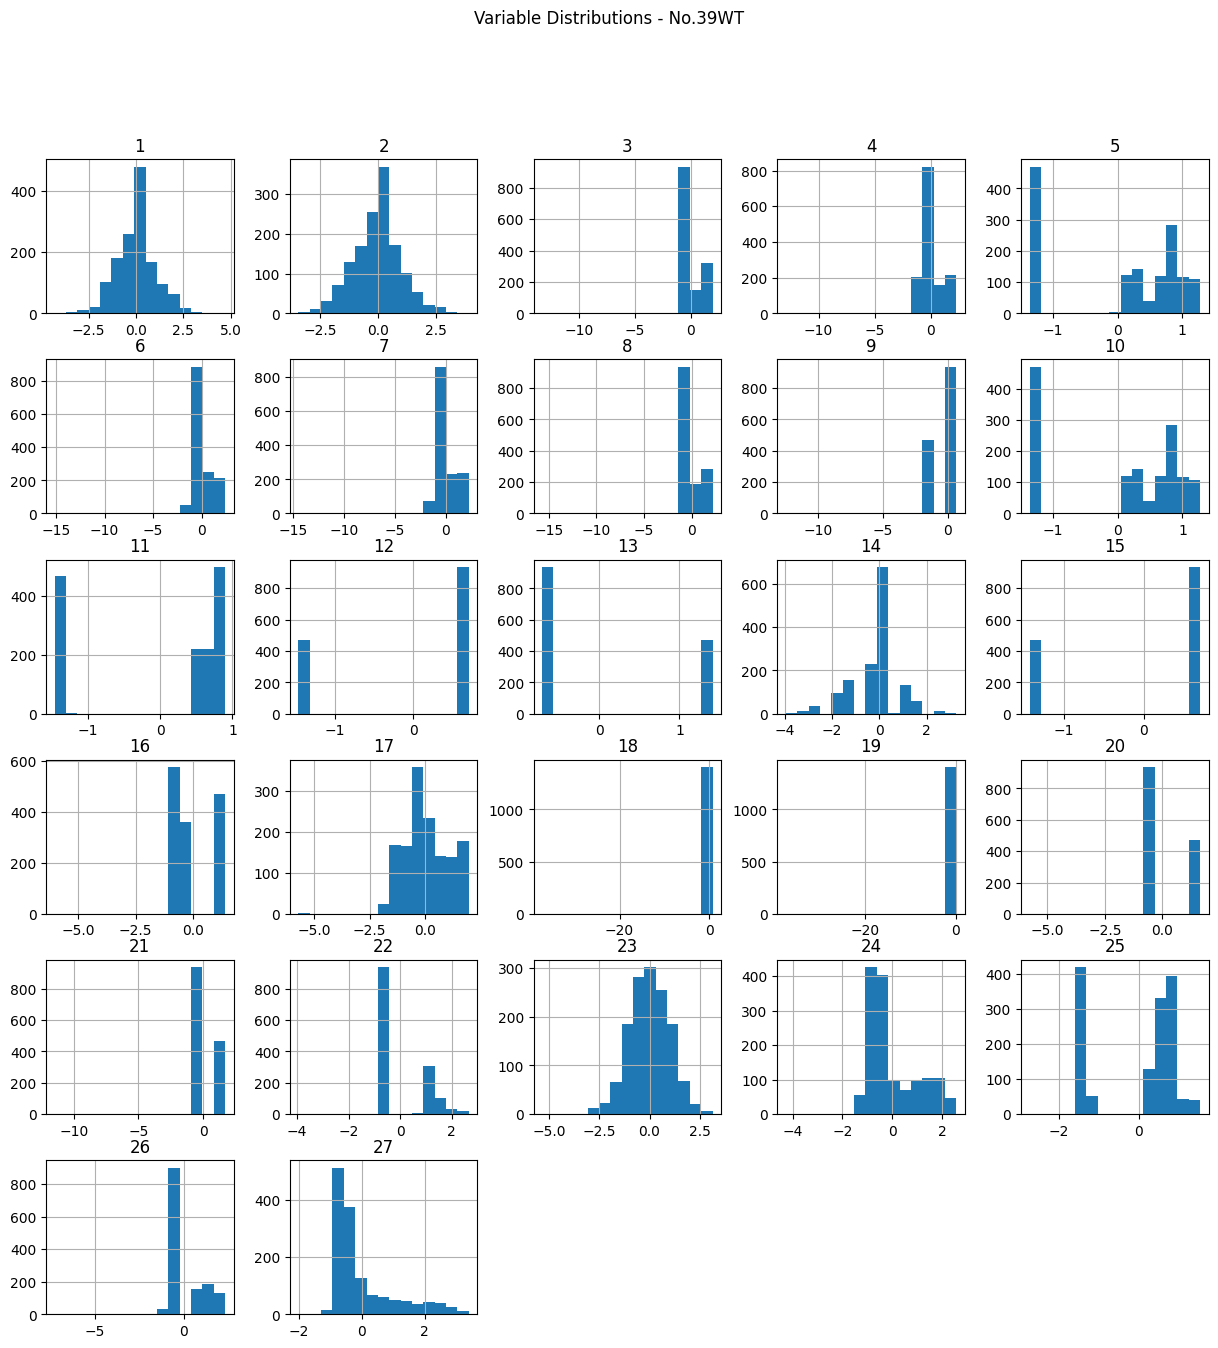

In [12]:
# Variable distributions
for sheet_name, df in data.items():
    df_norm = normalize_dataframe(df)
    df_norm.hist(bins=15, figsize=(15, 15))
    plt.suptitle(f"Variable Distributions - {sheet_name}")
    plt.savefig(f"Plots/Variable_Distributions_{sheet_name}.svg")
    plt.show()

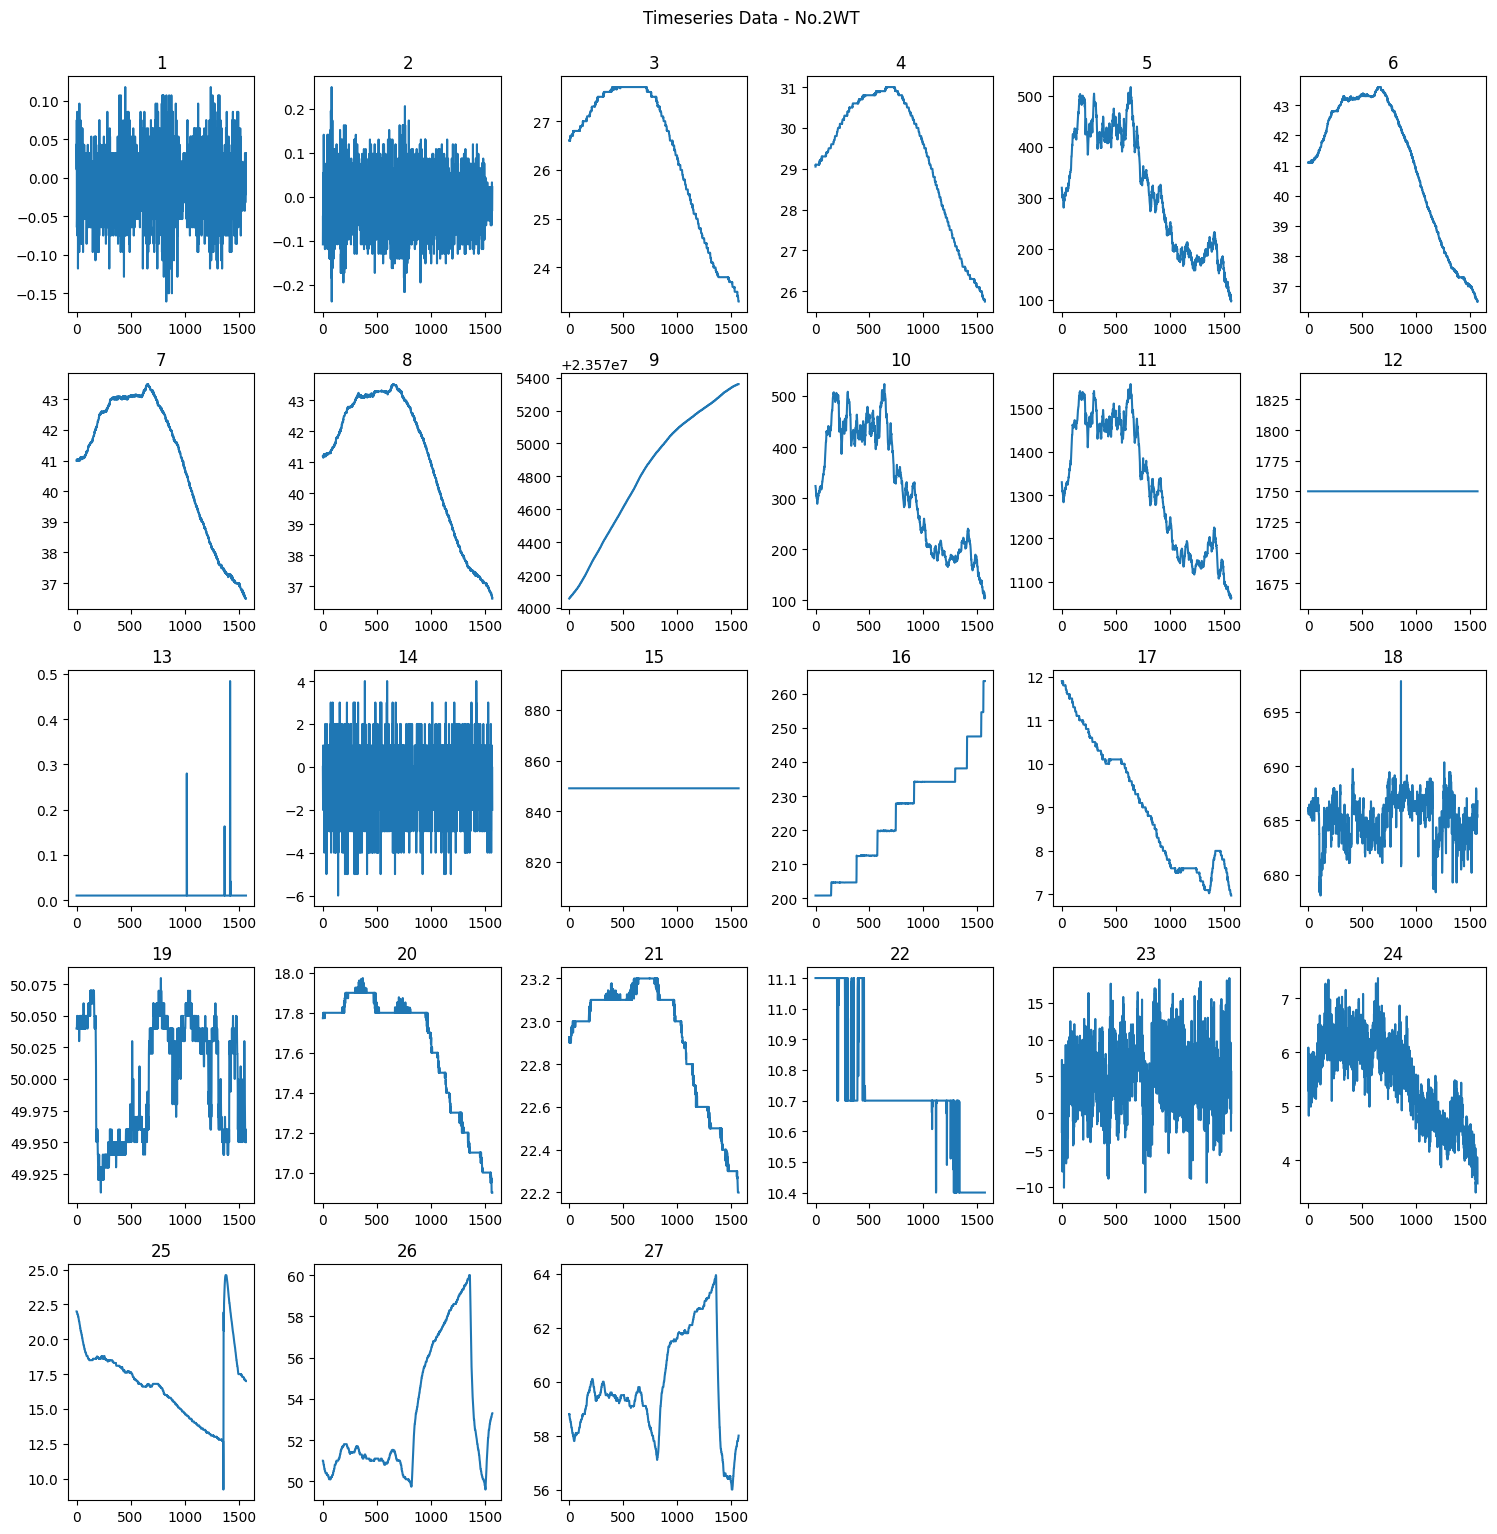

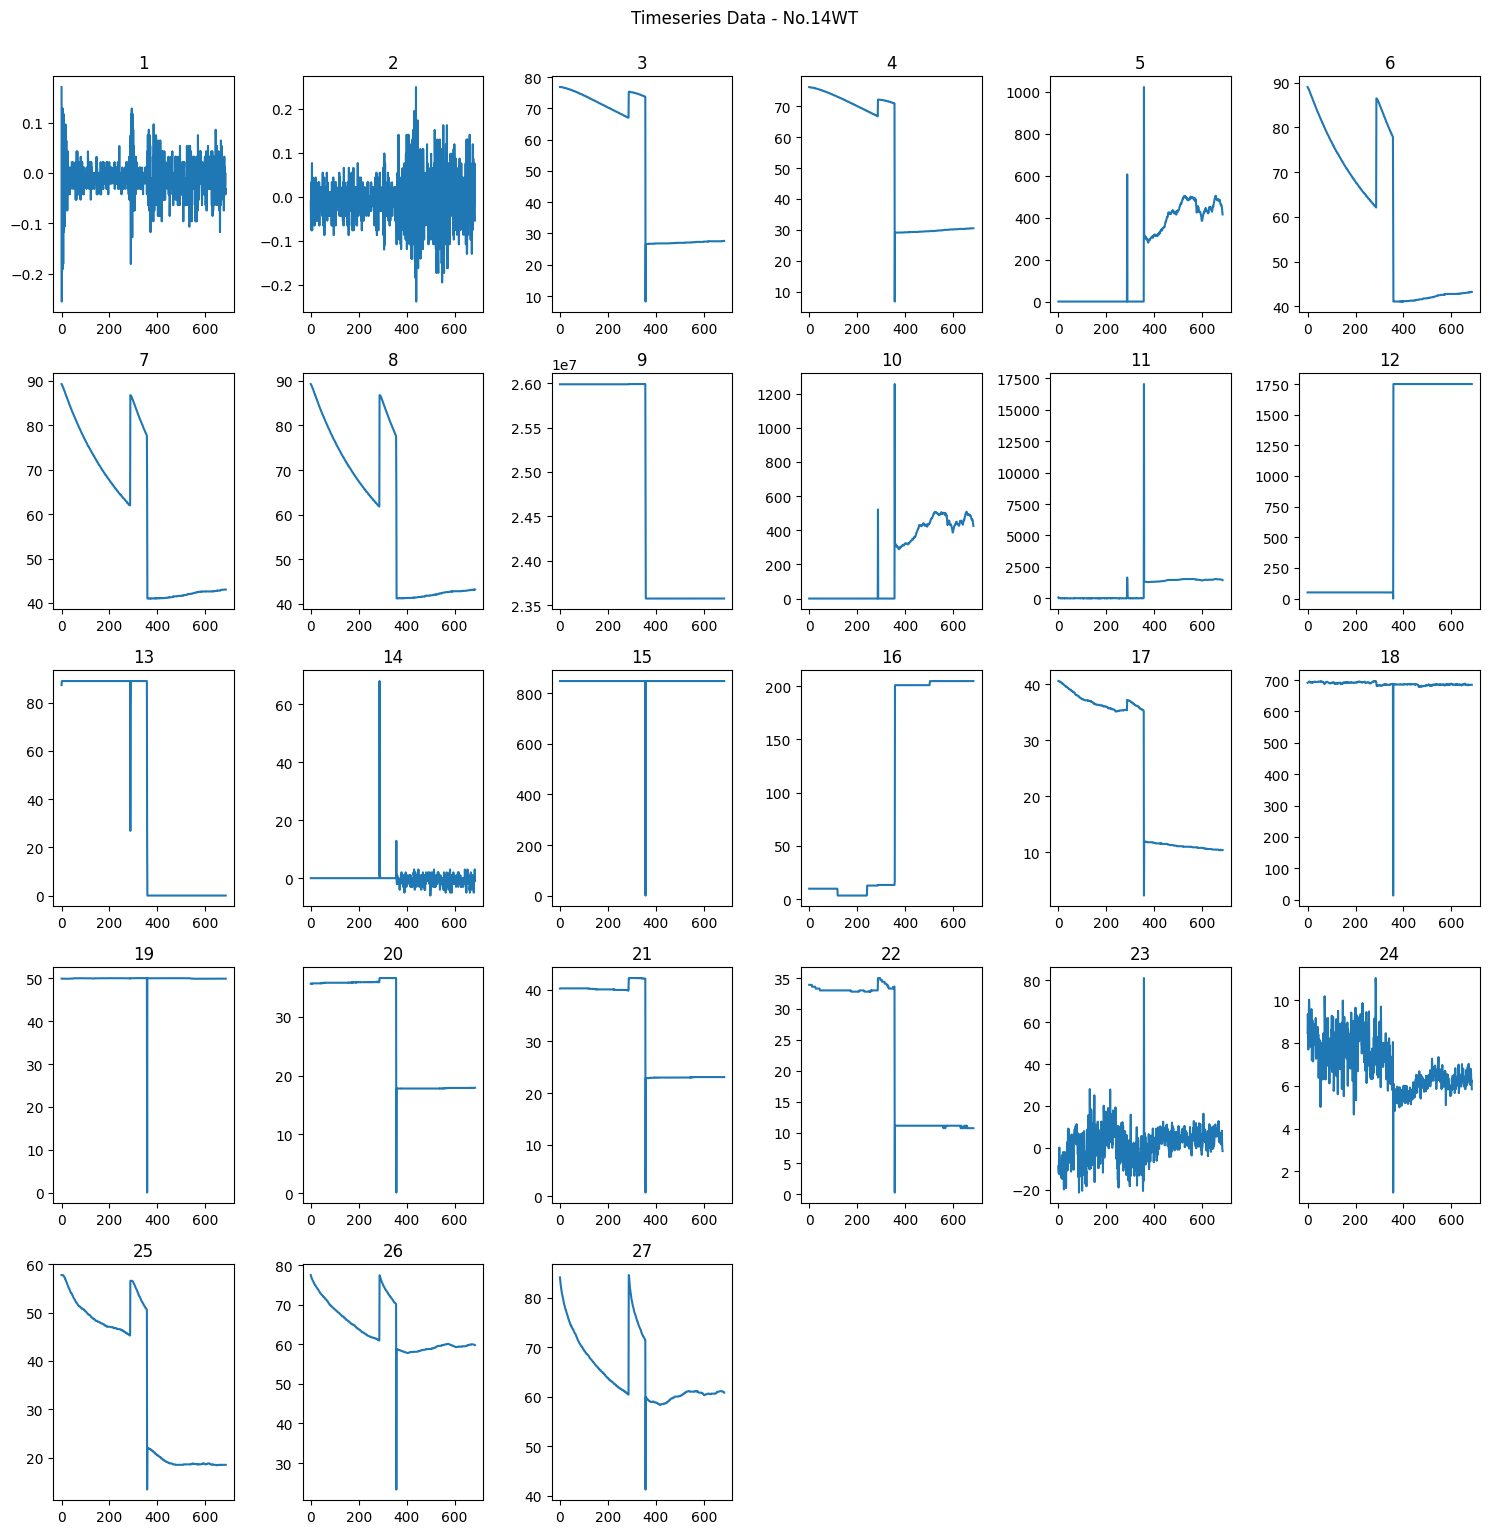

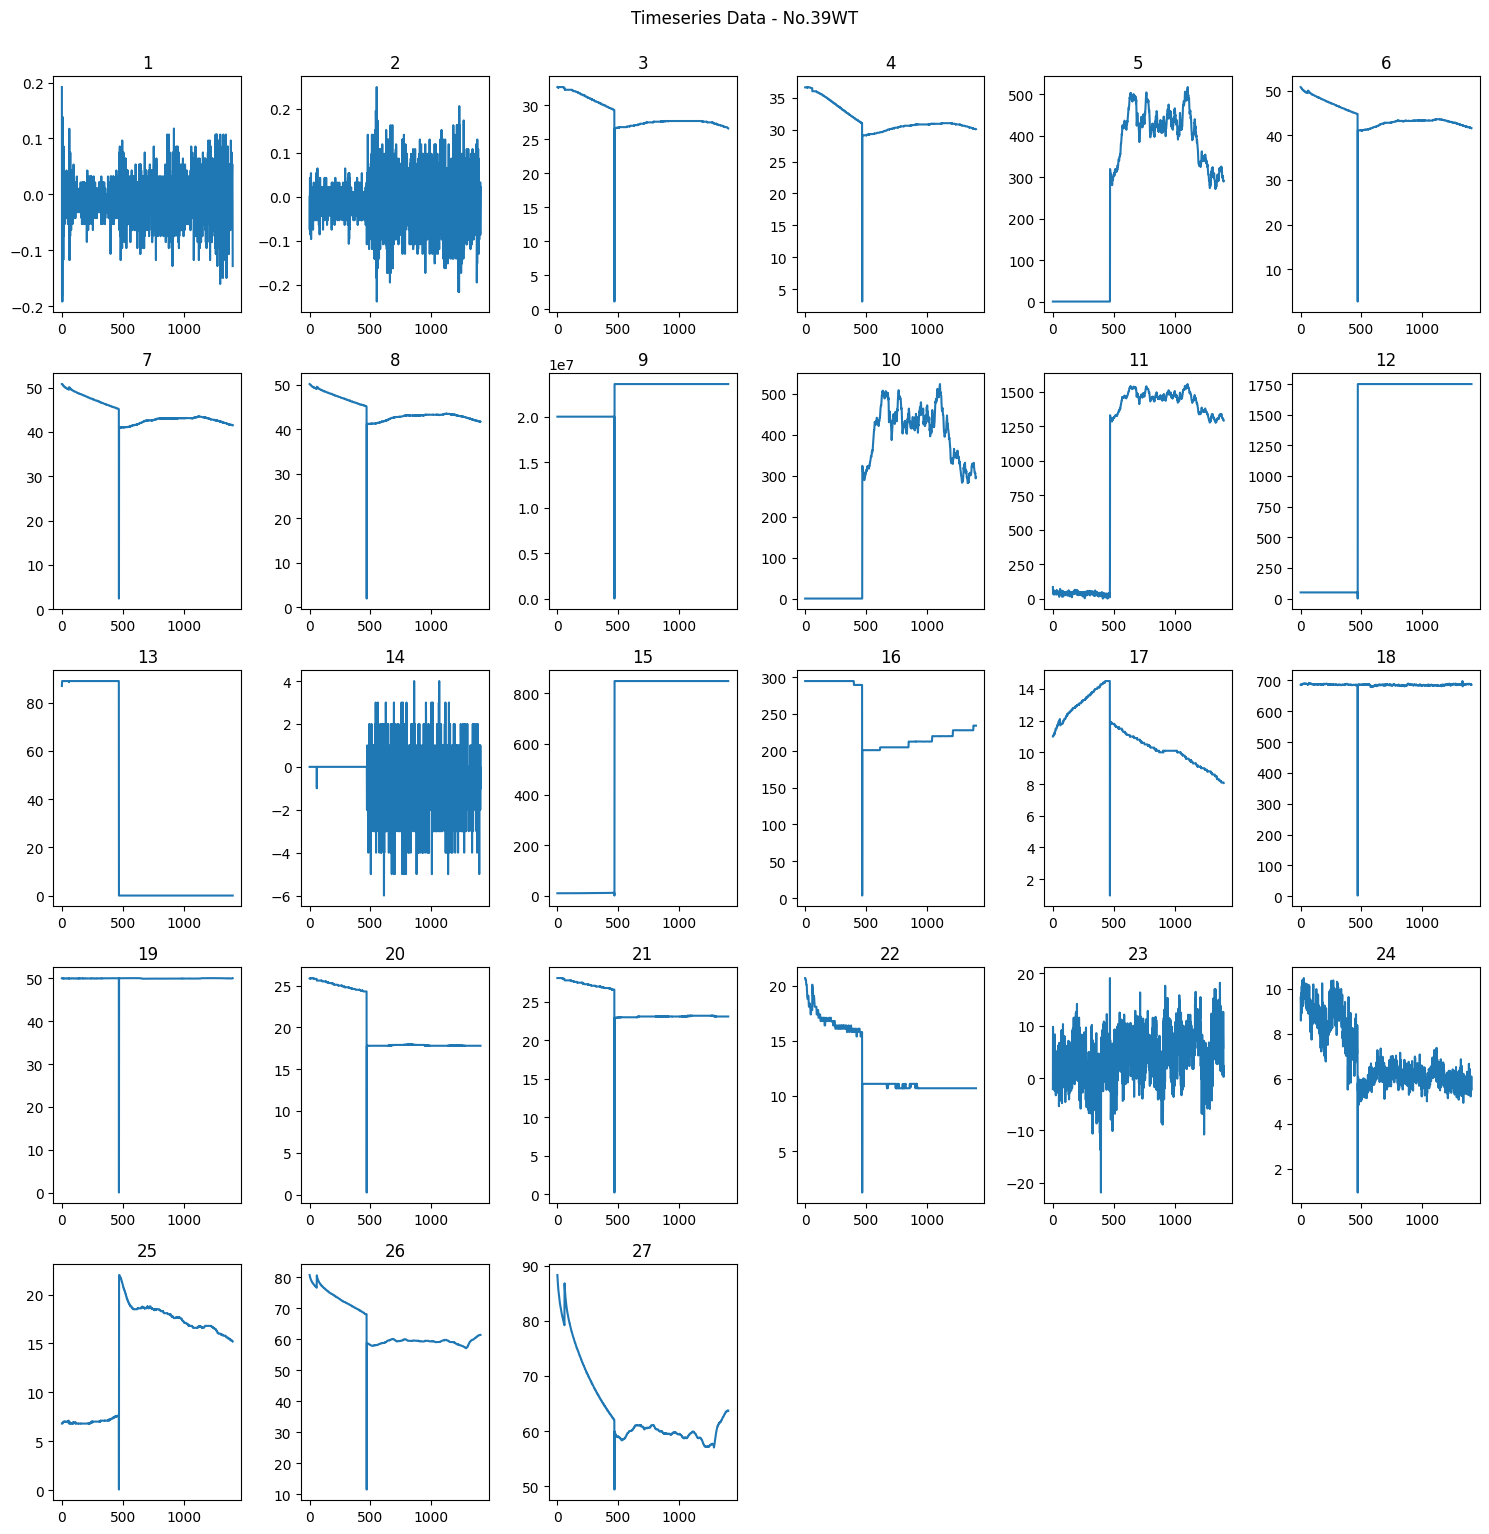

In [5]:
# Timeseries plots
for sheet_name, df in data.items():
    plt.figure(figsize=(15, 15))
    for i, col in enumerate(df.columns):
        plt.subplot(5, 6, i + 1)
        plt.plot(df[col])
        plt.title(col)
    plt.tight_layout()
    plt.suptitle(f"Timeseries Data - {sheet_name}", y=1.02)
    plt.savefig(f"Plots/Timeseries_Data_{sheet_name}.svg")
    plt.show()

### 2. Fit PCA models
PCA models are fit individually to all data sets used. For the faulty turbines, only the first 20 data points are used.

Helper functions

In [56]:
def fit_pca(df):
    pca = PCA()
    pca.fit(df)
    return pca

def get_variable_loadings(pca, df):
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    return pd.DataFrame(loadings, index=df.columns, columns=[f'PC{i+1}' for i in range(loadings.shape[1])])

def plot_pca_variance(df, sheet_name):
    pca = fit_pca(df)
    explained_variance = np.cumsum(pca.explained_variance_ratio_)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot cumulative explained variance
    axes[0].plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
    axes[0].set_title(f"PCA Cumulative Explained Variance - {sheet_name}")
    axes[0].set_xlabel('Number of Components')
    axes[0].set_ylabel('Cumulative Explained Variance')
    axes[0].grid(True)

    # Create a biplot
    pca_transformed = pca.transform(df)

    # autoscale normalization for both components
    pca_transformed[:, 0] = (pca_transformed[:, 0] - np.mean(pca_transformed[:, 0])) / np.std(pca_transformed[:, 0])
    pca_transformed[:, 1] = (pca_transformed[:, 1] - np.mean(pca_transformed[:, 1])) / np.std(pca_transformed[:, 1])

    axes[1].scatter(pca_transformed[:, 0], pca_transformed[:, 1], alpha=0.7, label='Data Points', c=pca_transformed[:, 0], cmap='viridis')
    for i, (pc1, pc2) in enumerate(zip(pca.components_[0], pca.components_[1])):
        axes[1].arrow(0, 0, pc1 * max(pca_transformed[:, 1]), pc2 * max(pca_transformed[:, 1]),
                      color='r', alpha=0.5, head_width=0.05, head_length=0.1)
        axes[1].text(pc1 * max(pca_transformed[:, 1]) * 1.1, 
                     pc2 * max(pca_transformed[:, 1]) * 1.1, 
                     df.columns[i], color='k', ha='center', va='center')
    axes[1].set_title(f"PCA Biplot - {sheet_name}")
    axes[1].set_xlabel('PC1')
    axes[1].set_ylabel('PC2')
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"Plots/PCA_Explained_Variance_and_Biplot_{sheet_name}.svg")
    plt.show()

Computing the PCA models and visualising the results

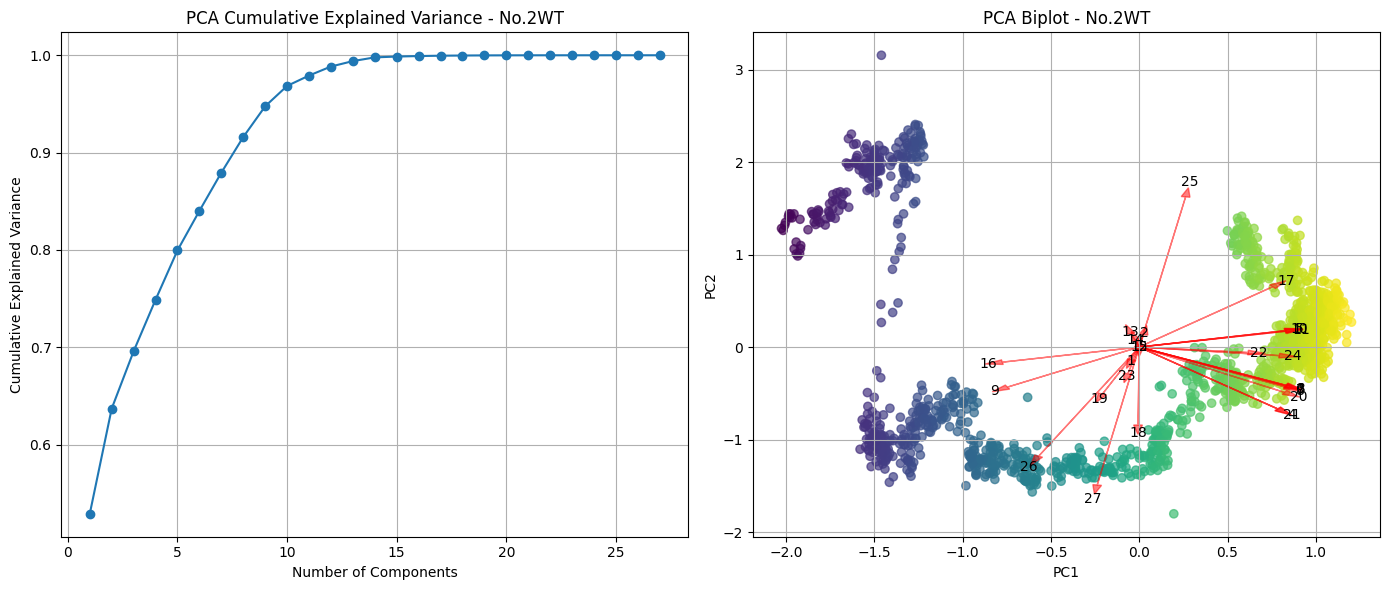

In [57]:
# PCA for healthy turbine
healthy_turbine = "No.2WT"
df_healthy = data[healthy_turbine]
df_healthy_norm = normalize_dataframe(df_healthy)
plot_pca_variance(df_healthy_norm, healthy_turbine)

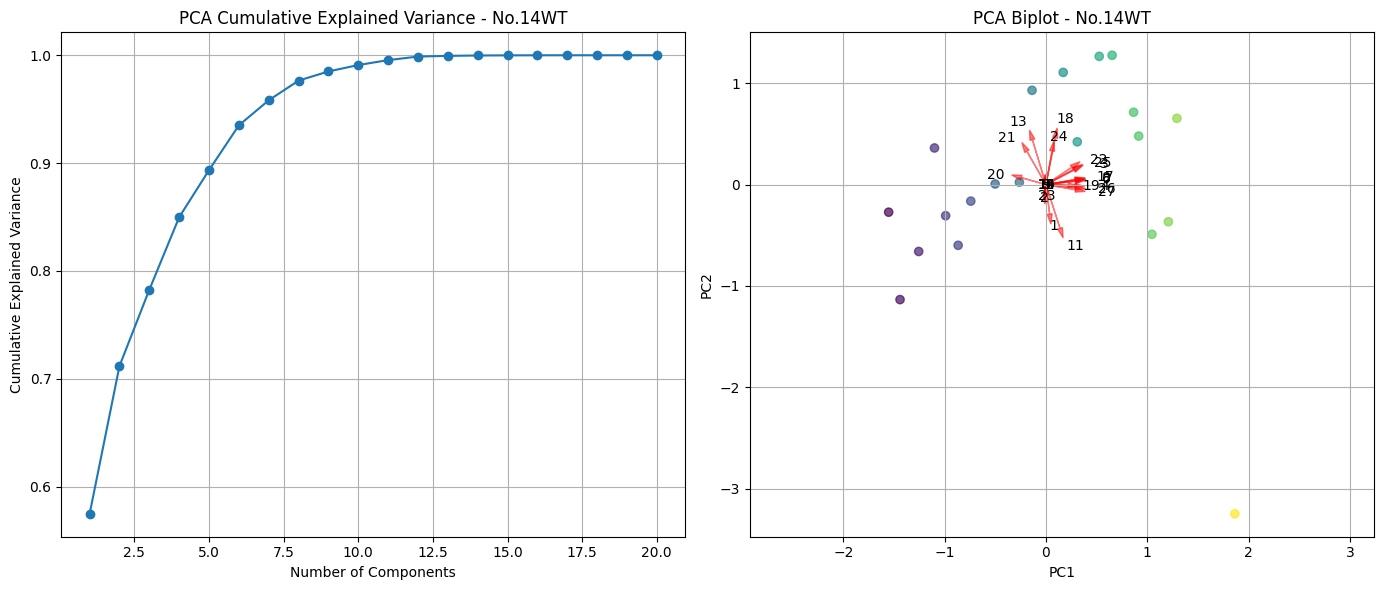

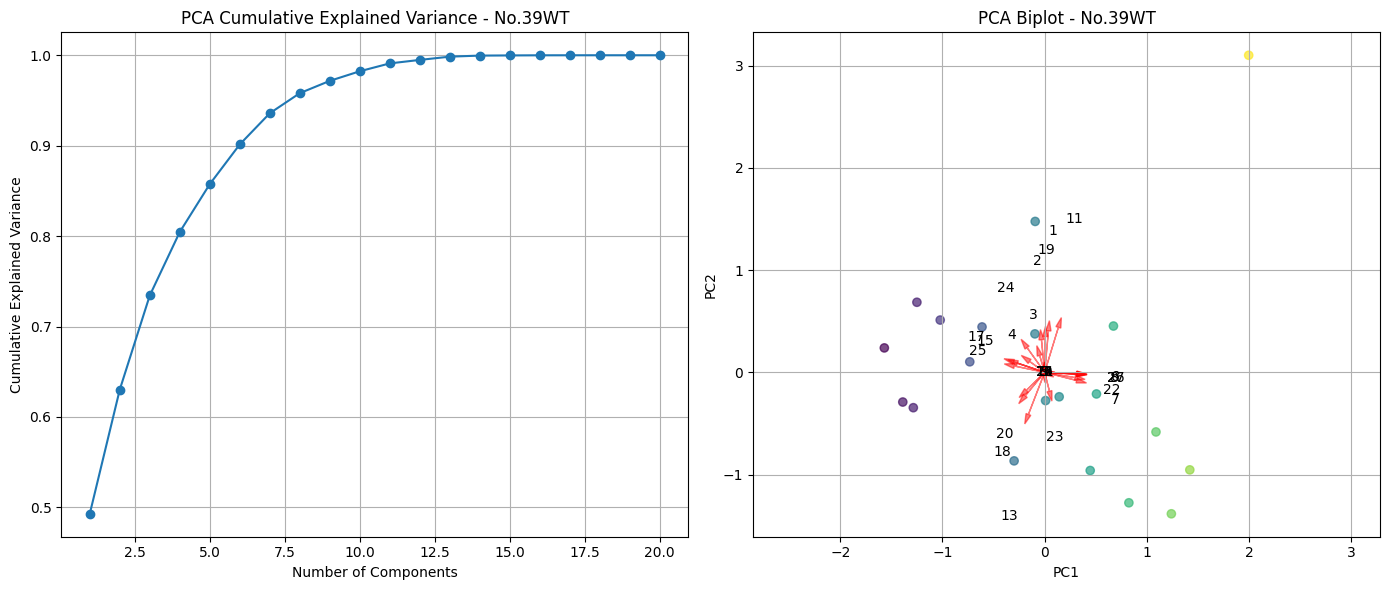

In [28]:
# PCA for faulty turbines, use only first 20 datapoints
for sheet_name, df in data.items():
    if sheet_name == healthy_turbine:
        continue
    df_faulty = df.iloc[:20, :]  # Use only first 20 datapoints
    df_faulty_norm = normalize_dataframe(df_faulty)
    plot_pca_variance(df_faulty_norm, sheet_name)

### 3. Identify the two most important sensors
Variable loadings for each sensor using two principal components are calculated. The loadings for the faulty turbines are averaged, and those values are compared to loadings of the healthy turbine. Based on the absolute differences, we choose two sensors that have the biggest difference in contributing to the principal components between healthy and faulty turbines.

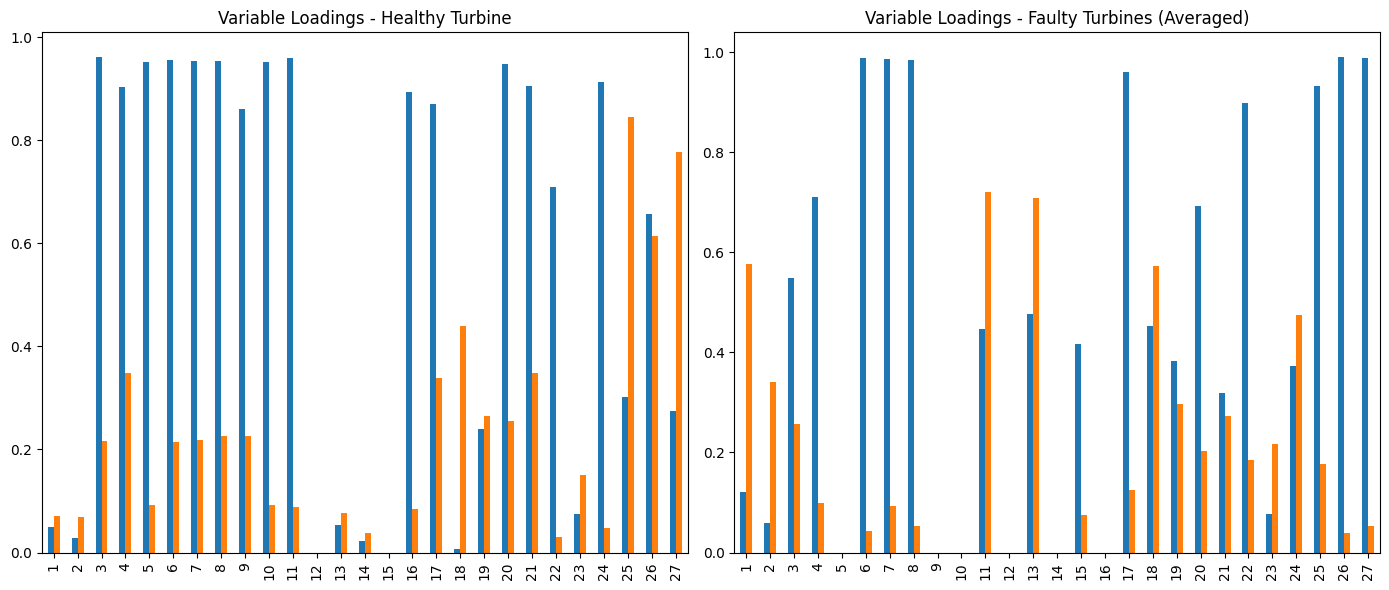

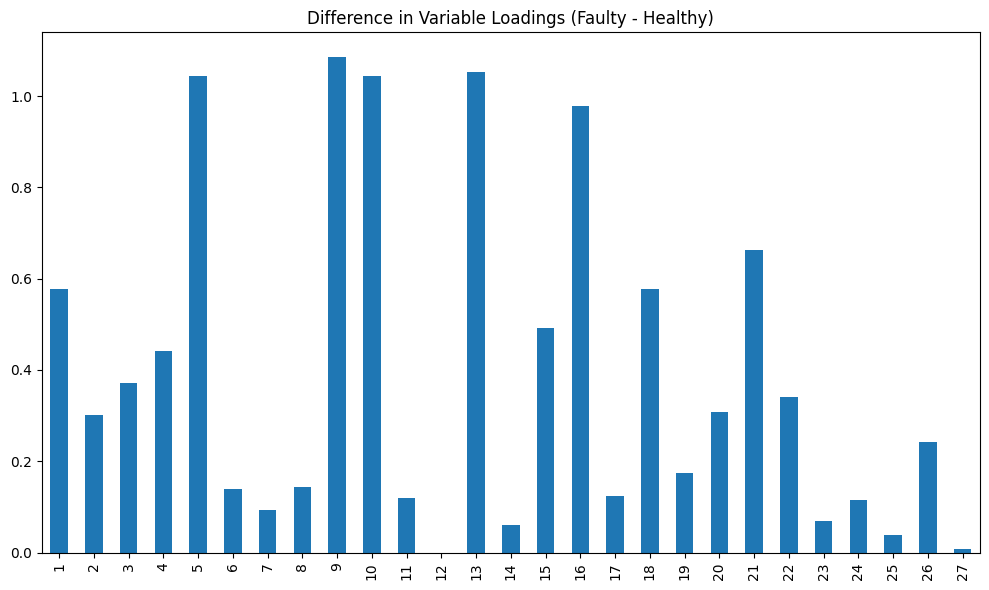

Two most different variables between healthy and faulty turbines:
9     1.085394
13    1.053226
dtype: float64


In [9]:
# Variable loadings for healthy turbine
loadings_healthy = pd.DataFrame(0, index=data[healthy_turbine].columns, columns=['PC1', 'PC2'])
for sheet_name, df in data.items():
    if sheet_name != healthy_turbine:
        continue
    df_norm = normalize_dataframe(df)
    pca = fit_pca(df_norm)
    loadings_healthy = get_variable_loadings(pca, df_norm).iloc[:, :2].abs()

# Variable loadings for faulty turbines, averaged
loadings_faulty_avg = pd.DataFrame(0, index=data[healthy_turbine].columns, columns=['PC1', 'PC2'])
for sheet_name, df in data.items():
    if sheet_name == healthy_turbine:
        continue
    df_faulty = df.iloc[:20, :]  # Use only first 20 datapoints
    df_faulty_norm = normalize_dataframe(df_faulty)
    pca = fit_pca(df_faulty_norm)
    loadings_faulty_avg += get_variable_loadings(pca, df_faulty_norm).iloc[:, :2].abs()
loadings_faulty_avg /= 2

# Visualizing the loadings for both healthy and the average of faulty turbines
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
loadings_healthy.plot(kind='bar', ax=axes[0], title='Variable Loadings - Healthy Turbine', legend=False)
loadings_faulty_avg.plot(kind='bar', ax=axes[1], title='Variable Loadings - Faulty Turbines (Averaged)', legend=False)
plt.tight_layout()
plt.savefig("Plots/Variable_Loadings_Comparison.svg")
plt.show()

# Plot differences in loadings, sum PC1 and PC2 absolute values
loadings_diff = abs(loadings_faulty_avg.sum(axis=1) - loadings_healthy.sum(axis=1))
loadings_diff.plot(kind='bar', figsize=(10, 6), title='Difference in Variable Loadings (Faulty - Healthy)', legend=False)
plt.tight_layout()
plt.savefig("Plots/Variable_Loadings_Difference.svg")
plt.show()

print(f"Two most different variables between healthy and faulty turbines:\n{loadings_diff.nlargest(2)}")

### 4. Train PLS model to predict the two sensors

In [10]:
# Train the PLS model to estimate the two most different variables for each faulty turbine based on the healthy turbine data
from sklearn.cross_decomposition import PLSRegression

# Define the two most different variables as target variables
top2_variables = [9,10]

# Prepare the healthy turbine data for training
X = df_healthy_norm.drop(columns=top2_variables)
y = df_healthy_norm[top2_variables]

# Create and fit the PLS model
pls = PLSRegression(n_components=2)
pls.fit(X, y)

PLSRegression()

### 5. Evaluate model accuracy
Let's try to predict the sensor values for the faulty turbines. Results are visualised and MSE values are shown.

Prediction error (MSE) for turbine No.14WT: 9590405.383601828
Q^2_CV for turbine No.14WT: -1.0922466429777455
Prediction error (MSE) for turbine No.39WT: 14848596.201512922
Q^2_CV for turbine No.39WT: -0.46480519024013844


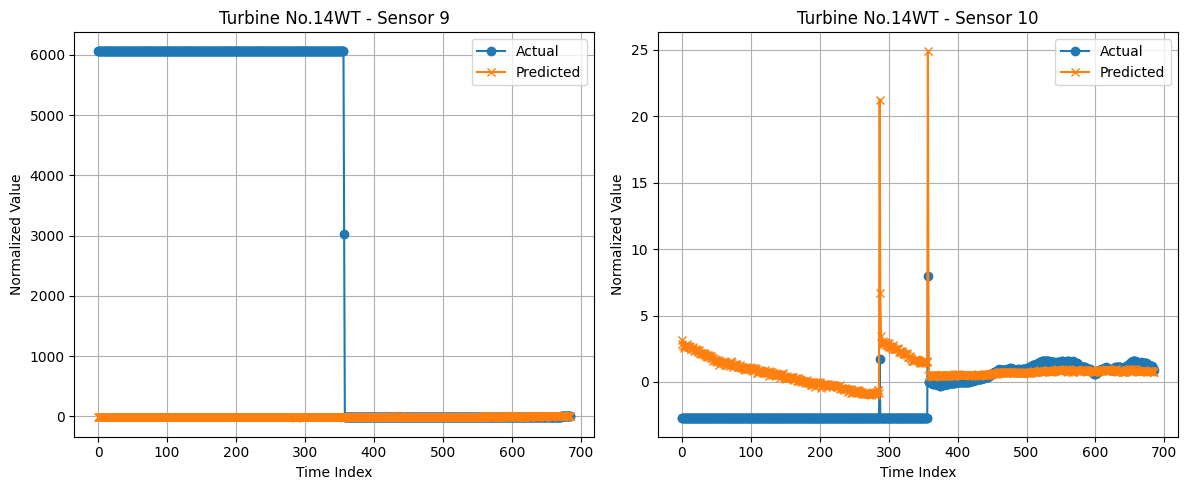

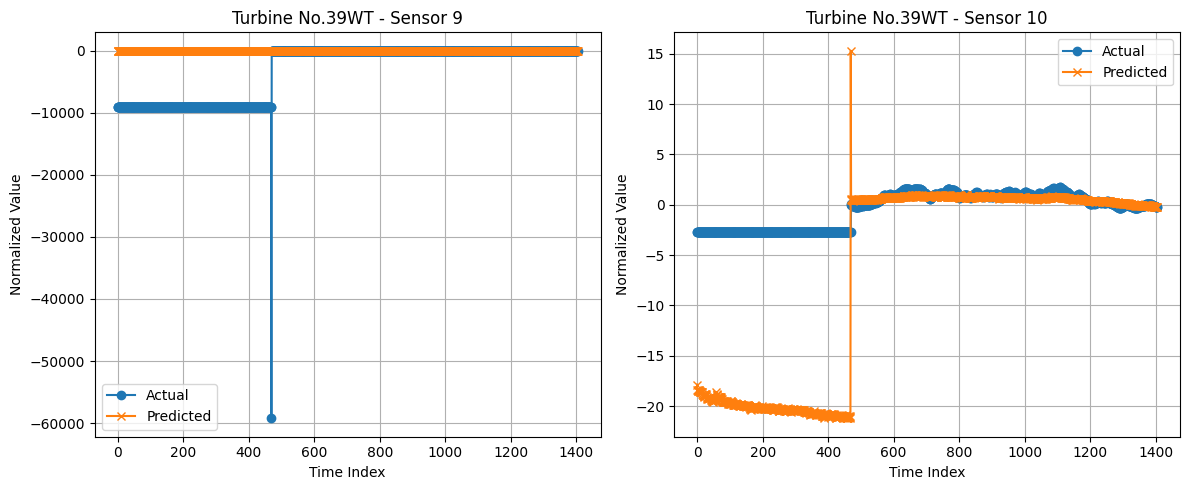

In [11]:
# Evaluate the PLS model using one of the faulty turbines as test data
for sheet_name, df in data.items():
    if sheet_name == healthy_turbine:
        continue 

    # Normalize the faulty turbine data using the same method
    df_faulty_norm = normalize_dataframe(df, mean=df_healthy.mean(), std=df_healthy.std())

    # Prepare the test data
    X_faulty = df_faulty_norm.drop(columns=top2_variables)
    y_faulty = df_faulty_norm[top2_variables]

    # Predict the values of the two important sensors
    y_pred = pls.predict(X_faulty)

    # Calculate the prediction error (e.g., mean squared error)
    mse = np.mean((y_faulty.values - y_pred) ** 2)
    print(f"Prediction error (MSE) for turbine {sheet_name}: {mse}")
    
    # Calculate the Q^2_CV value
    ss_total = np.sum((y_faulty.values - np.mean(y_faulty.values, axis=0)) ** 2)
    ss_residual = np.sum((y_faulty.values - y_pred) ** 2)
    q2_cv = 1 - (ss_residual / ss_total)
    print(f"Q^2_CV for turbine {sheet_name}: {q2_cv}")

    # Plot the actual vs predicted values for the two sensors
    plt.figure(figsize=(12, 5))
    for i, var in enumerate(top2_variables):
        plt.subplot(1, 2, i + 1)
        plt.plot(y_faulty.index, y_faulty[var], label='Actual', marker='o')
        plt.plot(y_faulty.index, y_pred[:, i], label='Predicted', marker='x')
        plt.title(f'Turbine {sheet_name} - Sensor {var}')
        plt.xlabel('Time Index')
        plt.ylabel('Normalized Value')
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"Plots/PLS_Prediction_{sheet_name}.svg")